In [34]:
import numpy as np
import density_field_library as DFL
import matplotlib.pyplot as plt
from math import pi

import Pk_library as PKL
import config as config
import my_remote_spectra as remote_spectra
# import remote_spectra as remote_spectra
import kszpsz_config as kszpsz_config

import importlib
from scipy.interpolate import RegularGridInterpolator
from scipy.interpolate import interp1d
import healpy as hp
import my_tools

In [3]:
Omega_b = config.Omega_b
Omega_c = config.Omega_c
w = config.w
wa = config.wa
Omega_K = config.Omega_K
h = config.h
As= config.As
ns = config.ns

In [8]:
grid              = 64  #grid size
BoxSize           = 30000.0 #Mpc
seed              = 1    #value of the initial random seed # varing seed
Rayleigh_sampling = 0     #whether sampling the Rayleigh distribution for modes amplitudes
threads           = 1      #number of openmp threads
verbose           = True   #whether to print some information

d = BoxSize/grid #Mpc
SampleRate = 1/d #1/Mpc
Max_k = 1/2*2*pi*SampleRate #h/Mpc, 2 from Nyquist theorem
Min_k = 2*pi/BoxSize #1/Mpc
print(f'd={d} Mpc') #Mpc/1
print(f'k_min = {Min_k} 1/Mpc') #1/Mpc
print(f'k_max = {Max_k} 1/Mpc') #1/Mpc

# k calculated by pylian3
kF,kN,kmax_par,kmax_per,kmax = PKL.frequencies(BoxSize, grid)
print(kF) #1/Mpc
print(kN) #1/Mpc

d=468.75 Mpc
k_min = 0.00020943951023931953 1/Mpc
k_max = 0.006702064327658226 1/Mpc
0.00020943951023931953
0.006702064327658225


In [9]:
# 3-d real space axes
d = BoxSize/grid #Mpc
x = np.arange(-BoxSize/2, BoxSize/2, d) #Mpc
y = np.arange(-BoxSize/2, BoxSize/2, d) #Mpc
z = np.arange(-BoxSize/2, BoxSize/2, d) #Mpc
# 3-d meshgrid coordinate 
# xx, yy = np.meshgrid(x, y)
xx, yy, zz = np.meshgrid(x, y, z)
rr = np.sqrt(xx**2 + yy**2 + zz**2)
print(xx.shape)

(64, 64, 64)


In [11]:
factor = 2*pi
k_x = factor*np.fft.fftfreq(grid, d)
k_y = factor*np.fft.fftfreq(grid, d)
k_z = factor*np.fft.fftfreq(grid, d)
kk_x, kk_y, kk_z = np.meshgrid(k_x, k_y, k_z)
kk  = np.sqrt(kk_x**2 + kk_y**2 + kk_z**2)
    
# kk_x_s, kk_y_s, kk_z_s = np.fft.fftshift(kk_x), np.fft.fftshift(kk_y), np.fft.fftshift(kk_z)
# kk_s  = np.sqrt(kk_x_s**2 + kk_y_s**2 + kk_z_s**2)
print(kk.shape)

(64, 64, 64)


# Import bubble collision parameters

In [18]:
# Now let's add the inhomogeneous potential psi_i_x where i for inhomogeneous
import param
importlib.reload(param)
A = param.A
B = param.B
direction = param.direction
z_c = param.z_c

A = 1
B = 0
direction = 'z'
z_c = 1
x_c = remote_spectra.chifromz(z_c) #Mpc
r_H = param.r_H #Mpc

Z_e = 1
a_e = 1/(1+Z_e)

if 1:
    print(A)
    print(B)
    print(z_c)
    print(x_c)
    print(f'r_H = {r_H} Mpc') #Mpc

1
0
1
3383.0757384546937
r_H = 4411.764705882353 Mpc


In [38]:
psi_i_x = A/r_H*(zz - x_c) + B/(r_H**2)*(zz - x_c)**2
psi_i_x[np.where(zz<x_c)] = 0
psi_i_k = np.fft.fftn(psi_i_x)

z
[0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.0831695 0.1894195
 0.2956695 0.4019195 0.5081695 0.6144195 0.7206695 0.8269195 0.9331695
 1.0394195 1.1456695 1.2519195 1.3581695 1.4644195 1.5706695 1.6769195
 1.7831695 1.8894195 1.9956695 2.1019195 2.2081695 2.3144195 2.4206695
 2.5269195]


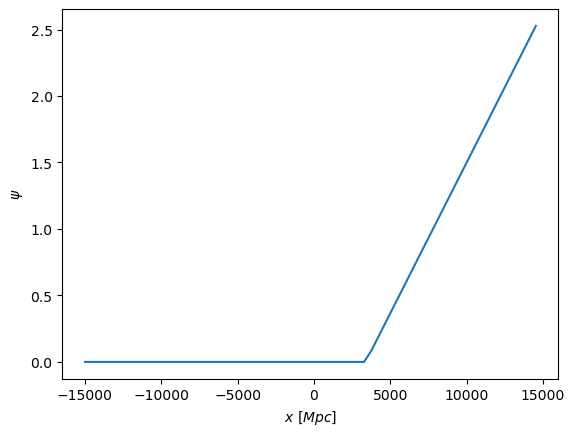

In [39]:
if 1:
    print(direction)
    if direction == 'x':
        plt.plot(x,psi_i_x[:, 0, 0])
    
    elif direction == 'y':
        plt.plot(x,psi_i_x[0, :, 0])
    
    elif direction == 'z':
        plt.plot(x,psi_i_x[0, 0, :])
        print(psi_i_x[0, 0, :])
    
    plt.xlabel(r'$x\ [Mpc]$')
    plt.ylabel(r'$\psi$')

In [40]:
if 0:
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    
    fig.colorbar(ax.scatter(xx,yy,zz,c=psi_i_x, s=0.01))
    ax.set_xlabel(r'x')
    ax.set_ylabel(r'y')
    ax.set_zlabel(r'z')
    ax.set_title(r'$\Psi_{i} (\mathbf{x})$');

# Choose the Ze of remote dipole field

In [41]:
r_e = remote_spectra.chifromz(Z_e)
r_edec = remote_spectra.chifromz(config.zdec) - remote_spectra.chifromz(Z_e)
r_dec = remote_spectra.chifromz(config.zdec)

print(f'r_c = {x_c} Mpc')
print(f'r_e = {r_e} Mpc')
print(f'r_edec = {r_edec} Mpc')
print(f'r_dec = {r_dec} Mpc')
print(f'r_H = {r_H} Mpc')

r_c = 3383.0757384546937 Mpc
r_e = 3383.0757384546937 Mpc
r_edec = 10457.993152490668 Mpc
r_dec = 13841.068890945362 Mpc
r_H = 4411.764705882353 Mpc


In [42]:
import my_remote_spectra
importlib.reload(my_remote_spectra)
from my_remote_spectra import T, G_SW_ksz, G_localDopp_ksz, G_Dopp_ksz, G_ISW_ksz

In [71]:
do_gradient = False
if do_gradient:
    Edge_order=2   
    g_psi_i_x = np.array([np.gradient(psi_i_x, d, edge_order=Edge_order)[1], np.gradient(psi_i_x, d, edge_order=Edge_order)[0], np.gradient(psi_i_x, d, edge_order=Edge_order)[2]])
else:
    g_psi_i_x3 = A/r_H + 2*B/(r_H**2)*(zz - x_c)
    g_psi_i_x3[np.where(zz<x_c)] = 0
    g_psi_i_x = np.array([np.zeros(xx.shape), np.zeros(xx.shape), g_psi_i_x3])

g_psi_i_k = np.array([np.fft.fftn(g_psi_i_x[0]), np.fft.fftn(g_psi_i_x[1]), np.fft.fftn(g_psi_i_x[2])])

z
[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.00022667 0.00022667
 0.00022667 0.00022667 0.00022667 0.00022667 0.00022667 0.00022667
 0.00022667 0.00022667 0.00022667 0.00022667 0.00022667 0.00022667
 0.00022667 0.00022667 0.00022667 0.00022667 0.00022667 0.00022667
 0.00022667 0.00022667 0.00022667 0.00022667]


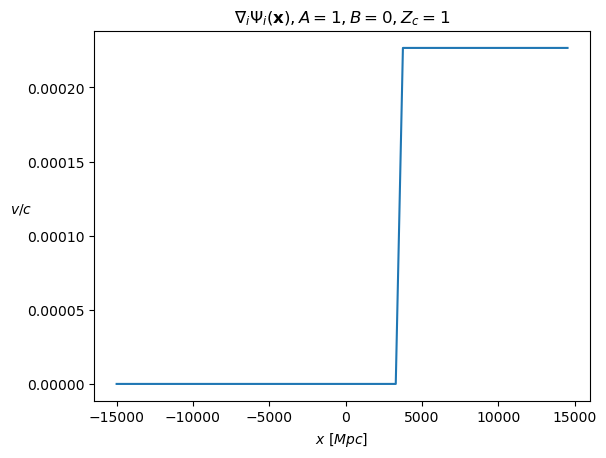

In [72]:
if 1:
    print(direction)
    if direction == 'x':
        plt.plot(x,g_psi_i_x[0].real[0, :, 0]) 
    elif direction == 'y':
        plt.plot(x,g_psi_i_x[1].real[:, 0, 0]) 
    elif direction == 'z':
        # V_eff_SW_x3.real = np.abs(V_eff_SW_x3.real)
        plt.plot(x,g_psi_i_x[2].real[0, 0, :])
        print(g_psi_i_x[2].real[0, 0, :])
    
    plt.title(r'$\nabla_i\Psi_{i} (\mathbf{x}), A=%s, B=%s, Z_{c}=%s$'%(A, B, z_c));
    plt.xlabel(r'$x\ [Mpc]$')
    plt.ylabel(r'$v/c$', rotation=0)

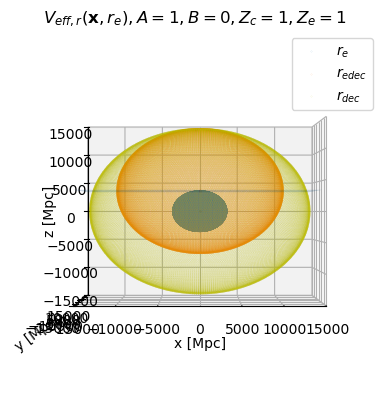

In [73]:
# try to plot the sphere on heapix plot
# https://healpy.readthedocs.io/en/latest/tutorial.html
NSIDE = 64
NPIX = hp.nside2npix(NSIDE)

theta_deg, phi_deg = np.degrees(hp.pix2ang(nside=NSIDE, ipix=np.arange(NPIX)))
theta = theta_deg * pi / 180.0
phi = phi_deg * pi / 180.0

x_e = r_e*np.sin(theta)*np.cos(phi) #Mpc
y_e = r_e*np.sin(theta)*np.sin(phi) #Mpc
z_e = r_e*np.cos(theta) #Mpc

if 0:
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')

    ax.scatter(x_e,y_e,z_e, s=0.2)
    # ax.set_xlim([-r_o, r_o])
    # ax.set_ylim([-r_o, r_o])
    # ax.set_zlim([-r_o, r_o])
    ax.set_xlabel(r'x')
    ax.set_ylabel(r'y')
    ax.set_zlabel(r'z')
    # ax.view_init(90, -90) 

# see https://stackoverflow.com/questions/11140163/plotting-a-3d-cube-a-sphere-and-a-vector and \
# https://stackoverflow.com/questions/64656951/plotting-spheres-of-radius-r
# check https://stackoverflow.com/questions/11140163/plotting-a-3d-cube-a-sphere-and-a-vector
# Z_e = 2
# a_e = 1/(1+Z_e)
# firstly obtain all the points at r_e = tau(a=1)-tau(a=a_e)
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# then plot the LSS for an electron at this sphere and the LSS for us
# pick a certain point at the sphere with coordinate of (a_e, x_e, y_e, z_e)

x_edec_s = r_edec*np.sin(theta)*np.cos(phi)
y_edec_s = r_edec*np.sin(theta)*np.sin(phi)
z_edec_s = r_edec*np.cos(theta)
# ax.scatter(x_e,y_e,z_e, color='r', s=10)

# get r_dec
# u, v = np.mgrid[0:2*np.pi:20j, 0:np.pi:20j]
x_dec_s = r_dec*np.sin(theta)*np.cos(phi)
y_dec_s = r_dec*np.sin(theta)*np.sin(phi)
z_dec_s = r_dec*np.cos(theta)

ax.scatter(x_e, y_e, z_e, alpha=0.4, label=r'$r_{e}$', s=0.01)
ax.scatter(x_edec_s+x_e[0], y_edec_s+y_e[0], z_edec_s+z_e[0], alpha=0.4, label=r'$r_{edec}$', s=0.01)
ax.scatter(x_dec_s, y_dec_s, z_dec_s, color='y', alpha=0.4, label=r'$r_{dec}$', s=0.01)
ax.scatter(0,0,0, color='k', s=1)
ax.scatter(x_e[0],y_e[0],z_e[0], color='r', s=2)


yy_c, zz_c = np.meshgrid(y, z)
xx_c = x_c*np.ones_like(yy_c)
if direction == 'x':
    ax.plot_surface(xx_c, yy_c, zz_c, alpha=0.2)
if direction == 'y':
    ax.plot_surface(yy_c, xx_c, zz_c, alpha=0.2)
elif direction == 'z':
    ax.plot_surface(yy_c, zz_c, xx_c, alpha=0.2)

ax.set_xlim([-BoxSize/2, BoxSize/2])
ax.set_ylim([-BoxSize/2, BoxSize/2])
ax.set_zlim([-BoxSize/2,BoxSize/2])
ax.set_xlabel(r'x [Mpc]')
ax.set_ylabel(r'y [Mpc]')
ax.set_zlabel(r'z [Mpc]')
ax.set_title(r'$V_{eff, r}(\mathbf{x}, r_e), A=%s, B=%s, Z_{c}=%s, Z_{e}=%s$'%(A, B, z_c, Z_e))
ax.legend()
ax.view_init(0, -90) 

In [74]:
importlib.reload(my_tools)
from my_tools import Evolve

EV = Evolve(kk, Z_e, Omega_b, Omega_c, w, wa, Omega_K, h)

RDF_locaDopp_x3 = EV.RDF_component_Evolve_localDopp(psi_i_k, kk_z).real
RDF_SW_x3 = EV.RDF_component_Evolve_SW(psi_i_k, kk_z).real



In [75]:
RDF_locaDopp_x3_test = EV.RDF_gradient_Evolve_localDopp(g_psi_i_k[2]).real

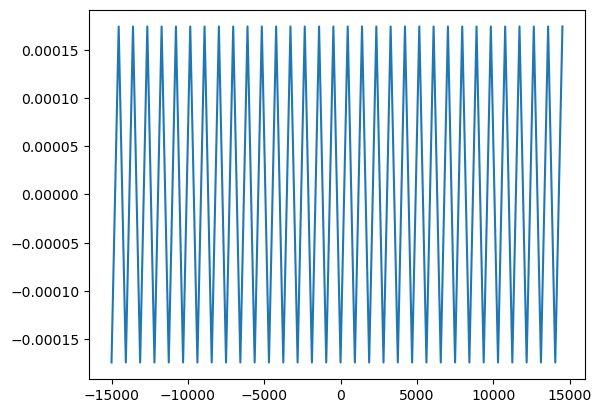

In [69]:
plt.plot(x, RDF_localDopp_x3[0, 0, :])
plt.plot(x, RDF_localDopp_x3[0, 0, :])